# 04 Biotech Funding and Disease Burden EDA

This notebook explores biotech funding and disease burden data for the Global Healthcare & Pharma Analytics project.

The goal is to understand funding trends, deal types, megadeal concentration, disease burden patterns, regional burden differences, and early signals of possible mismatch between investment activity and real-world healthcare need during the 2010–2025 main analysis period.

In [1]:
# Import core libraries
# Reference: 01_data_quality_check.ipynb - Step 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set display options
# Reference: 01_data_quality_check.ipynb - Step 1
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# Load datasets needed for this notebook
# Reference: 01_data_quality_check.ipynb - Step 3
biotech_funding = pd.read_csv("biotech_funding.csv")
disease_burden = pd.read_csv("disease_burden.csv")

# Convert date column
# Reference: 01_data_quality_check.ipynb - Step 13
biotech_funding["date"] = pd.to_datetime(biotech_funding["date"])

# Create main analysis period datasets: 2010–2025
# Reference: 02_financial_performance_eda.ipynb - Main analysis period definition
biotech_funding_main = biotech_funding[
    (biotech_funding["year"] >= 2010) & (biotech_funding["year"] <= 2025)
]

disease_burden_main = disease_burden[
    (disease_burden["year"] >= 2010) & (disease_burden["year"] <= 2025)
]

## Step 2: Validate Main Analysis Datasets

This step checks the shape and year range of the filtered biotech funding and disease burden datasets.

In [2]:
dataset_check = pd.DataFrame({
    "dataset": ["biotech_funding_main", "disease_burden_main"],
    "rows": [biotech_funding_main.shape[0], disease_burden_main.shape[0]],
    "columns": [biotech_funding_main.shape[1], disease_burden_main.shape[1]],
    "min_year": [biotech_funding_main["year"].min(), disease_burden_main["year"].min()],
    "max_year": [biotech_funding_main["year"].max(), disease_burden_main["year"].max()]
})

dataset_check

,dataset,rows,columns,min_year,max_year
0,biotech_funding_main,1201,10,2010,2025
1,disease_burden_main,3110,5,2010,2025


## Step 3: Preview Biotech Funding and Disease Burden Datasets

This step previews the filtered biotech funding and disease burden datasets to confirm the available columns before analysis.

In [3]:
display(biotech_funding_main.head())
display(disease_burden_main.head())

,deal_id,date,year,deal_type,acquirer_or_investors,target_or_company,value_usd_bn,description,is_megadeal,is_real_headline
1,D0041,2010-01-08,2010,Series_B,F-Prime Capital,Oncgen OS,0.403,Series_B 2010,0,0
2,D0036,2010-01-12,2010,IPO,Public markets,Yothap IO,0.456,IPO 2010,0,0
3,D0045,2010-01-16,2010,M&A,Roche,Aermod AB,1.158,M&A 2010,0,0
4,D0053,2010-01-17,2010,Series_B,Polaris Partners,Tavyot OS,0.643,Series_B 2010,0,0
5,D0046,2010-01-17,2010,Crossover,GV (Google Ventures),Repyot RX,0.348,Crossover 2010,0,0


,year,region,disease,dalys_millions,global_dalys_millions
0,2010,North America,Cardiovascular disease,18.49,350.0
1,2010,Western Europe,Cardiovascular disease,20.94,350.0
2,2010,Eastern Europe,Cardiovascular disease,13.05,350.0
3,2010,China,Cardiovascular disease,60.71,350.0
4,2010,India,Cardiovascular disease,66.51,350.0


## Step 4: Biotech Funding by Year

This step calculates and visualizes total biotech funding value by year between 2010 and 2025. It helps identify funding growth, peak years, and possible investment cycle effects.

,year,deal_count,total_funding_usd_bn,avg_deal_value_usd_bn,megadeal_count
0,2010,35,16.166,0.461886,0
1,2011,45,51.771,1.150467,2
2,2012,50,64.842,1.296840,1
3,2013,55,58.597,1.065400,2
4,2014,62,174.812,2.819548,4
5,2015,71,155.178,2.185606,5
6,2016,66,54.723,0.829136,1
7,2017,75,71.004,0.946720,2
8,2018,88,48.237,0.548148,0
9,2019,72,282.487,3.923431,6


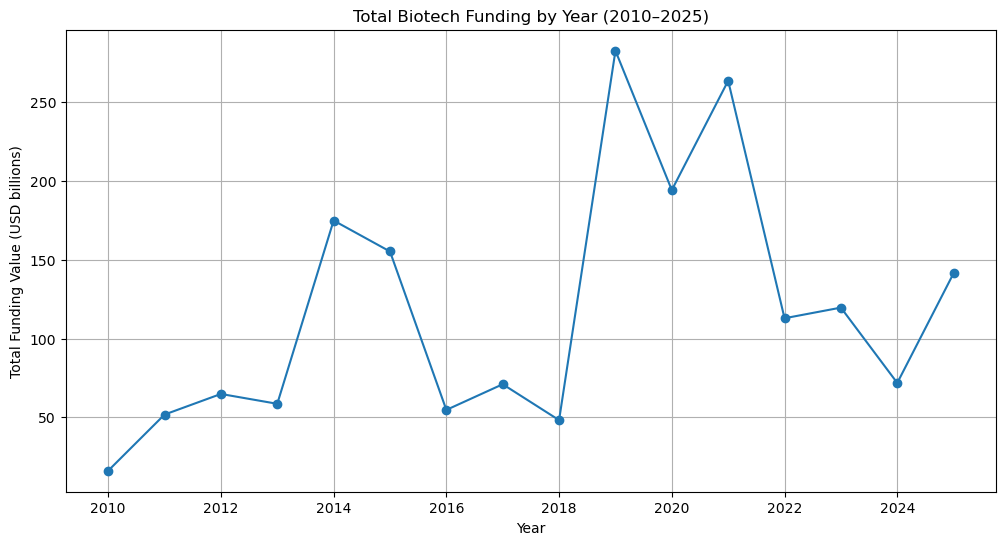

In [4]:
funding_by_year = (
    biotech_funding_main
    .groupby("year")
    .agg(
        deal_count=("deal_id", "count"),
        total_funding_usd_bn=("value_usd_bn", "sum"),
        avg_deal_value_usd_bn=("value_usd_bn", "mean"),
        megadeal_count=("is_megadeal", "sum")
    )
    .reset_index()
)

display(funding_by_year)

plt.figure(figsize=(12, 6))
plt.plot(
    funding_by_year["year"],
    funding_by_year["total_funding_usd_bn"],
    marker="o"
)

plt.title("Total Biotech Funding by Year (2010–2025)")
plt.xlabel("Year")
plt.ylabel("Total Funding Value (USD billions)")
plt.grid(True)
plt.show()

### Biotech Funding Trend Observation

Biotech funding showed strong year-to-year volatility between 2010 and 2025.

Total funding reached major peaks in 2019 and 2021, suggesting that funding activity was strongly influenced by large transactions and megadeals rather than only by deal count.

The 2021 peak also aligns with a period of increased biotech and healthcare market attention following the COVID era. However, the funding decline after 2021 suggests that investment activity became more selective or less inflated in later years.

This indicates that biotech funding should be analyzed using both total funding value and deal count, because a small number of large deals can strongly influence yearly totals.

## Step 6: Biotech Funding by Deal Type

This step summarizes biotech funding by deal type. It compares deal count, total funding value, average deal value, and megadeal count across deal categories.

,deal_type,deal_count,total_funding_usd_bn,avg_deal_value_usd_bn,megadeal_count
0,M&A,192,1604.635,8.357474,47
1,VC,465,105.584,0.227062,0
2,IPO,134,71.050,0.530224,0
3,Series_B,231,56.825,0.245996,0
4,Series_C,118,29.517,0.250144,0
5,Crossover,61,13.452,0.220525,0


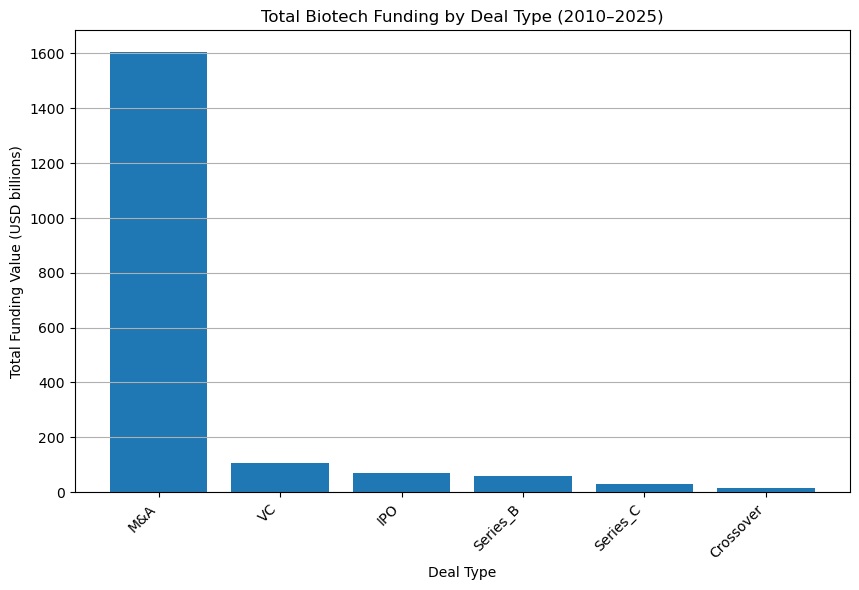

In [5]:
funding_by_deal_type = (
    biotech_funding_main
    .groupby("deal_type")
    .agg(
        deal_count=("deal_id", "count"),
        total_funding_usd_bn=("value_usd_bn", "sum"),
        avg_deal_value_usd_bn=("value_usd_bn", "mean"),
        megadeal_count=("is_megadeal", "sum")
    )
    .sort_values("total_funding_usd_bn", ascending=False)
    .reset_index()
)

display(funding_by_deal_type)

plt.figure(figsize=(10, 6))
plt.bar(
    funding_by_deal_type["deal_type"],
    funding_by_deal_type["total_funding_usd_bn"]
)

plt.title("Total Biotech Funding by Deal Type (2010–2025)")
plt.xlabel("Deal Type")
plt.ylabel("Total Funding Value (USD billions)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

### Deal Type Funding Observation

Biotech funding value was highly concentrated in M&A transactions between 2010 and 2025.

VC had the highest number of deals, but M&A dominated total funding value due to much larger average deal sizes and a high number of megadeals.

This shows that deal count and funding value tell different stories. VC activity reflects broad early-stage investment activity, while M&A reflects large-scale strategic capital deployment and market consolidation.

## Step 8: Megadeal Share and Funding Concentration

This step calculates the share of megadeals and compares their contribution to total funding value. It helps evaluate whether a small number of large deals dominate biotech funding.

In [6]:
megadeal_summary = pd.DataFrame({
    "category": ["All Deals", "Megadeals", "Non-Megadeals"],
    "deal_count": [
        biotech_funding_main["deal_id"].count(),
        biotech_funding_main[biotech_funding_main["is_megadeal"] == 1]["deal_id"].count(),
        biotech_funding_main[biotech_funding_main["is_megadeal"] == 0]["deal_id"].count()
    ],
    "total_funding_usd_bn": [
        biotech_funding_main["value_usd_bn"].sum(),
        biotech_funding_main[biotech_funding_main["is_megadeal"] == 1]["value_usd_bn"].sum(),
        biotech_funding_main[biotech_funding_main["is_megadeal"] == 0]["value_usd_bn"].sum()
    ]
})

megadeal_summary["deal_share_pct"] = (
    megadeal_summary["deal_count"] / megadeal_summary.loc[0, "deal_count"]
) * 100

megadeal_summary["funding_share_pct"] = (
    megadeal_summary["total_funding_usd_bn"] / megadeal_summary.loc[0, "total_funding_usd_bn"]
) * 100

megadeal_summary

,category,deal_count,total_funding_usd_bn,deal_share_pct,funding_share_pct
0,All Deals,1201,1881.063,100.000000,100.000000
1,Megadeals,47,1316.427,3.913405,69.983143
2,Non-Megadeals,1154,564.636,96.086595,30.016857


### Megadeal Concentration Observation

Megadeals represented only approximately 3.9% of all biotech funding deals between 2010 and 2025, but accounted for approximately 70.0% of total funding value.

This indicates a highly concentrated funding structure where a small number of very large transactions dominate total capital flow.

As a result, biotech funding should be interpreted carefully: deal count reflects market activity, while total funding value is heavily influenced by megadeals.

# Disease Burden Analysis

This section explores disease burden patterns between 2010 and 2025. The analysis focuses on disease-level and regional DALY patterns to understand where healthcare burden is concentrated.

## Step 10: Disease Burden by Disease

This step calculates average and total disease burden by disease during the 2010–2025 main analysis period.

,disease,record_count,avg_dalys_millions,total_dalys_millions,avg_global_dalys_millions
0,Cardiovascular disease,160,38.398062,6143.69,384.781250
1,Neurological disorders,160,25.588000,4094.08,255.312500
2,Cancer,160,24.653313,3944.53,246.906250
3,Mental disorders,160,16.715625,2674.50,165.687500
4,Neonatal disorders,160,16.291812,2606.69,163.343750
5,Stroke,160,14.308500,2289.36,142.812500
6,Chronic respiratory,160,10.243750,1639.00,102.187500
7,Lower respiratory infections,160,9.634562,1541.53,96.156250
8,Diabetes,160,7.562500,1210.00,75.375000
9,Road injuries,160,7.400250,1184.04,73.875000


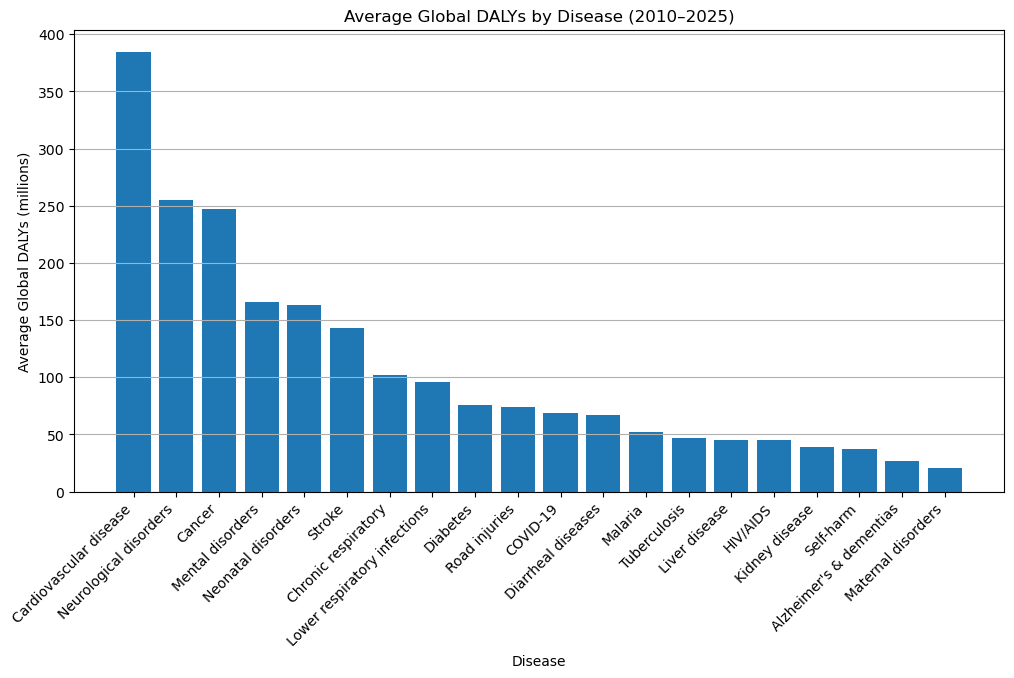

In [7]:
burden_by_disease = (
    disease_burden_main
    .groupby("disease")
    .agg(
        record_count=("disease", "count"),
        avg_dalys_millions=("dalys_millions", "mean"),
        total_dalys_millions=("dalys_millions", "sum"),
        avg_global_dalys_millions=("global_dalys_millions", "mean")
    )
    .sort_values("avg_global_dalys_millions", ascending=False)
    .reset_index()
)

display(burden_by_disease)

plt.figure(figsize=(12, 6))
plt.bar(
    burden_by_disease["disease"],
    burden_by_disease["avg_global_dalys_millions"]
)

plt.title("Average Global DALYs by Disease (2010–2025)")
plt.xlabel("Disease")
plt.ylabel("Average Global DALYs (millions)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

### Disease Burden by Disease Observation

Disease burden was not evenly distributed across disease groups between 2010 and 2025.

Cardiovascular disease had the highest average global DALYs, followed by neurological disorders, cancer, mental disorders, neonatal disorders, and stroke.

This creates an important contrast with the drug approvals analysis, where oncology dominated approval activity and estimated peak sales. Cancer has a high disease burden, but cardiovascular disease and neurological disorders also represent very large global burden areas.

This suggests that later innovation gap analysis should compare disease burden rankings with drug approval, clinical trial, and funding activity rankings.

## Step 12: Disease Burden by Region

This step calculates average and total disease burden by region during the 2010–2025 main analysis period. It helps identify which regions carry the highest burden across diseases.

,region,record_count,avg_dalys_millions,total_dalys_millions
0,Africa,311,24.294051,7555.45
1,India,311,21.717717,6754.21
2,China,311,19.675209,6118.99
3,Southeast Asia,311,10.865595,3379.20
4,Middle East,311,7.636752,2375.03
5,Latin America,311,7.624952,2371.36
6,Western Europe,311,7.412733,2305.36
7,North America,311,5.969743,1856.59
8,Eastern Europe,311,4.367460,1358.28
9,Oceania,311,1.081768,336.43


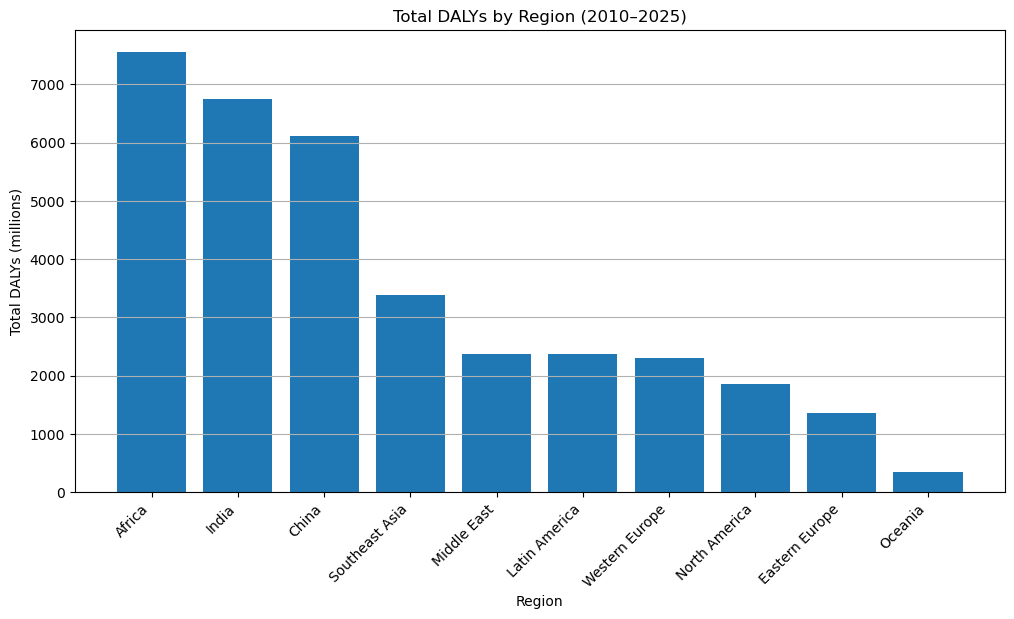

In [8]:
burden_by_region = (
    disease_burden_main
    .groupby("region")
    .agg(
        record_count=("region", "count"),
        avg_dalys_millions=("dalys_millions", "mean"),
        total_dalys_millions=("dalys_millions", "sum")
    )
    .sort_values("total_dalys_millions", ascending=False)
    .reset_index()
)

display(burden_by_region)

plt.figure(figsize=(12, 6))
plt.bar(
    burden_by_region["region"],
    burden_by_region["total_dalys_millions"]
)

plt.title("Total DALYs by Region (2010–2025)")
plt.xlabel("Region")
plt.ylabel("Total DALYs (millions)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

### Regional Disease Burden Observation

Disease burden was highly concentrated across regions between 2010 and 2025.

Africa had the highest total DALYs, followed by India and China. Southeast Asia also showed a high total burden compared with most other regions.

North America, Western Europe, Eastern Europe, and Oceania showed lower total DALYs in this dataset. This regional pattern suggests that later analysis should consider whether pharmaceutical innovation and investment activity align with the regions carrying the highest health burden.

## Step 14: Disease Burden Trend by Year

This step calculates and visualizes total DALYs by year across all diseases and regions. It helps identify whether overall disease burden increased, decreased, or remained stable during the main analysis period.

,year,total_dalys_millions,avg_dalys_millions
0,2010,2112.62,11.119053
1,2011,2091.57,11.008263
2,2012,2105.60,11.082105
3,2013,2113.87,11.125632
4,2014,2103.59,11.071526
5,2015,2089.48,10.997263
6,2016,2097.40,11.038947
7,2017,2092.33,11.012263
8,2018,2101.71,11.061632
9,2019,2093.35,10.466750


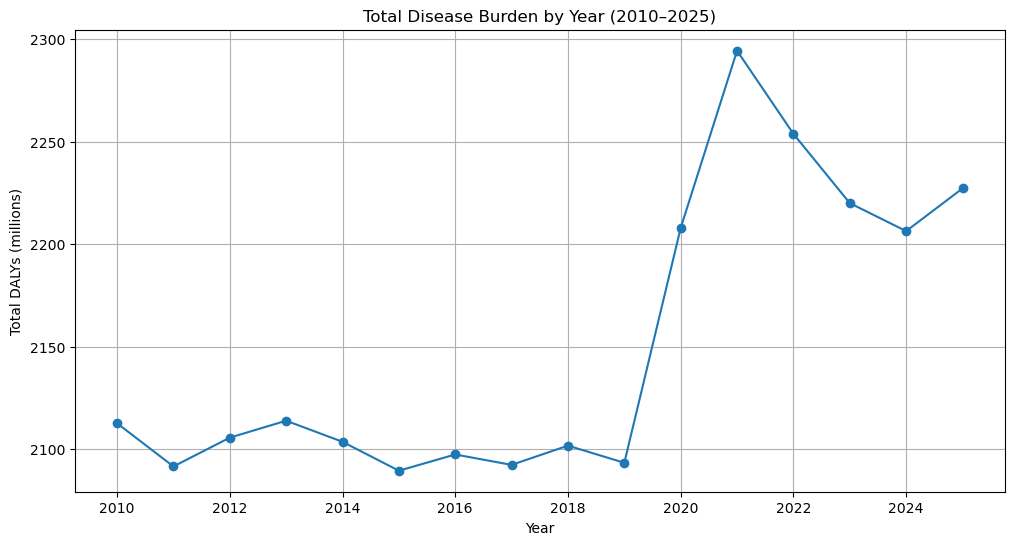

In [10]:
burden_by_year = (
    disease_burden_main
    .groupby("year")
    .agg(
        total_dalys_millions=("dalys_millions", "sum"),
        avg_dalys_millions=("dalys_millions", "mean")
    )
    .reset_index()
)

display(burden_by_year)

plt.figure(figsize=(12, 6))
plt.plot(
    burden_by_year["year"],
    burden_by_year["total_dalys_millions"],
    marker="o"
)

plt.title("Total Disease Burden by Year (2010–2025)")
plt.xlabel("Year")
plt.ylabel("Total DALYs (millions)")
plt.grid(True)
plt.show()

### Disease Burden Trend Observation

Total disease burden remained relatively stable between 2010 and 2019.

A clear increase appears in 2020 and reaches the highest level in 2021. Although total DALYs declined after 2021, the post-2020 values remained higher than most pre-2020 years.

This suggests that the post-2020 period represents a major shift in overall disease burden. Later analysis should consider how this change relates to COVID-era funding, infectious disease activity, and broader pharmaceutical innovation patterns.

## Biotech Funding and Disease Burden Interim Summary

The biotech funding and disease burden analysis shows several important patterns:

- Biotech funding was highly volatile between 2010 and 2025.
- Total funding value peaked in 2019 and 2021.
- M&A dominated total funding value, while VC had the highest number of deals.
- Megadeals represented only around 4% of all deals but accounted for around 70% of total funding value.
- Disease burden was highest for cardiovascular disease, neurological disorders, and cancer.
- Cancer was dominant in drug approvals and estimated peak sales, but cardiovascular disease had the highest average global DALYs.
- Regionally, disease burden was highest in Africa, India, and China.
- Total disease burden increased sharply after 2020 and peaked in 2021.

These findings suggest that biotech investment activity and real-world disease burden may follow different concentration patterns. This creates a strong foundation for the next notebook, where innovation activity will be compared directly with disease burden.

# Notebook Summary and Next Steps

This notebook completed the exploratory analysis of biotech funding and disease burden for the 2010–2025 main analysis period.

Key biotech funding findings:

- Biotech funding showed strong year-to-year volatility.
- Total funding value peaked in 2019 and 2021.
- VC had the highest number of deals, but M&A dominated total funding value.
- M&A deals had much larger average deal values than other deal types.
- Megadeals represented only around 4% of all deals but accounted for around 70% of total funding value.
- This indicates that total biotech funding value was highly concentrated in a small number of very large transactions.

Key disease burden findings:

- Cardiovascular disease had the highest average global DALYs.
- Neurological disorders and cancer were also among the highest-burden disease groups.
- Disease burden was regionally concentrated, with Africa, India, and China showing the highest total DALYs.
- Total disease burden remained relatively stable from 2010 to 2019, increased sharply in 2020, and peaked in 2021.
- Post-2020 disease burden remained higher than most pre-2020 years.

Overall interpretation:

Biotech funding and disease burden appear to follow different concentration patterns. Funding value is strongly shaped by deal type and megadeals, while disease burden is concentrated around major public health challenges such as cardiovascular disease, neurological disorders, cancer, and regional burden in Africa, India, and China.

This creates a strong foundation for the next notebook, where company financials, drug approvals, clinical trials, biotech funding, and disease burden will be connected through custom KPIs and innovation gap analysis.

The next notebook will focus on:

- Approval productivity
- R&D intensity by company and segment
- Trial success rates by therapy area
- Innovation activity by therapy area
- Disease burden versus innovation activity
- Innovation gap score
- Funding per burden and approval per burden